<a href="https://colab.research.google.com/github/Ayaawasis-collab/Projek-Anreg/blob/main/progres%201%20projek%20wasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projek Anreg Wasis

In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, shapiro
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson

In [ ]:
# LOAD DATA
data = pd.read_csv("StudentsPerformance.csv")

print(data.head())
print(data.tail())
print(data.info())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
     gender race/ethnicity parental level of education         lunch  \
995  female        group E             master's degree      standard   
996    male    

In [ ]:
# ANALISIS DATA HILANG

print("\nANALISIS DATA HILANG")

total_missing = data.isna().sum().sum()
print("Total missing:", total_missing)

missing_per_var = data.isna().sum()
print("\nMissing per variabel:")
print(missing_per_var)


ANALISIS DATA HILANG
Total missing: 0

Missing per variabel:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [ ]:
# STATISTIK DESKRIPTIF
print("\nSTATISTIK DESKRIPTIF")
print(data.describe())


STATISTIK DESKRIPTIF
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


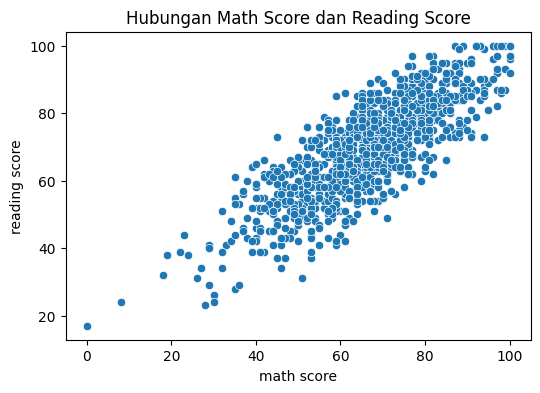

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="math score", y="reading score", data=data)

plt.title("Hubungan Math Score dan Reading Score")
plt.show()

In [ ]:
# KORELASI PEARSON
corr, pval = pearsonr(data["math score"], data["reading score"])

print("Korelasi Pearson =", round(corr,4))
print("p-value =", round(pval,4))

Korelasi Pearson = 0.8176
p-value = 0.0


In [ ]:
# MODEL REGRESI
X = data["math score"]
Y = data["reading score"]

X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          reading score   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     2012.
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          1.79e-241
Time:                        15:36:48   Log-Likelihood:                -3547.5
No. Observations:                1000   AIC:                             7099.
Df Residuals:                     998   BIC:                             7109.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.1418      1.190     14.405      0.0

In [ ]:
residuals = model.resid

stat, p = shapiro(residuals)

print("\nUJI NORMALITAS")
print("Statistik =", round(stat,5))
print("p-value =", round(p,5))

alpha = 0.05
if p > alpha:
    print("Residual NORMAL")
else:
    print("Residual TIDAK normal")


UJI NORMALITAS
Statistik = 0.99557
p-value = 0.00543
Residual TIDAK normal


In [ ]:
bp_test = sms.het_breuschpagan(residuals, model.model.exog)

print("\nUJI HOMOSKEDASTISITAS")
print("p-value =", round(bp_test[1],4))


UJI HOMOSKEDASTISITAS
p-value = 0.143


In [ ]:
# UJI AUTOKORELASI (Durbin-Watson).
dw_statistic = dw

print("\n3. UJI AUTOKORELASI (Durbin-Watson):")
print(f"   Statistik DW = {dw_statistic:.4f}")

if 1.5 < dw_statistic < 2.5:
    print("   Keputusan: Tidak terdapat autokorelasi (berdasarkan aturan umum DW)")
else:
    print("   Keputusan: Terdapat kemungkinan autokorelasi (berdasarkan aturan umum DW)")


3. UJI AUTOKORELASI (Durbin-Watson):
   Statistik DW = 2.0252
   Keputusan: Tidak terdapat autokorelasi (berdasarkan aturan umum DW)


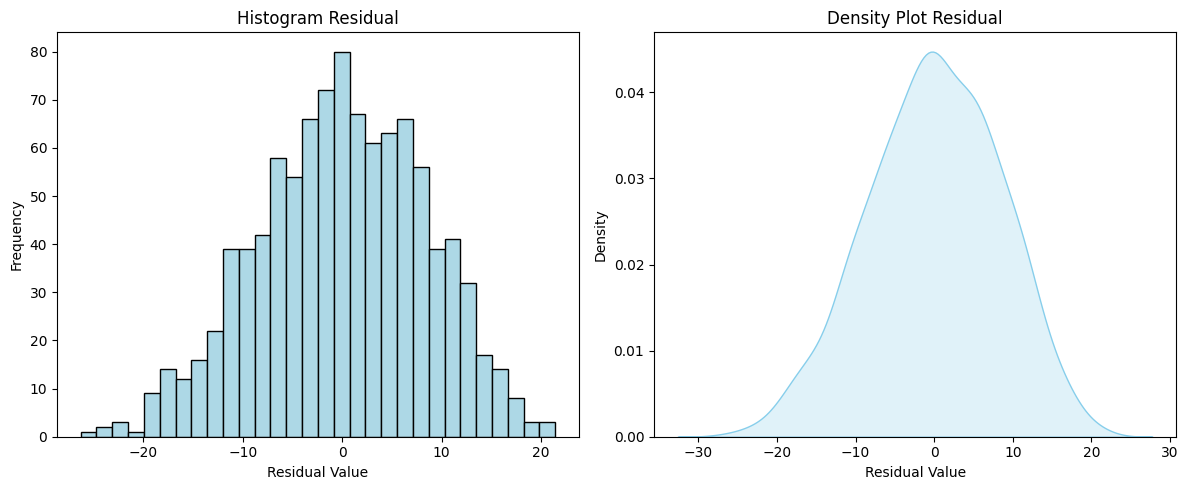

In [ ]:
# Histogram residual
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, color='lightblue', edgecolor='black')
plt.title("Histogram Residual")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")

# Density residual
plt.subplot(1, 2, 2)
sns.kdeplot(residuals, fill=True, color='skyblue')
plt.title("Density Plot Residual")
plt.xlabel("Residual Value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


In [ ]:

alpha = 0.05

print("\nInterpretasi Normalitas:")

if p > alpha:
    print("Residual dapat dianggap mendekati normal.")
else:
    print("Residual tidak normal secara statistik, namun model masih valid jika sampel besar.")


Interpretasi Normalitas:
Residual tidak normal secara statistik, namun model masih valid jika sampel besar.
